# Preparation 

This example uses the following packages. You may use your favourite plotting tools instead.
- numpy
- h5py
- h5flow (See the instructions in readme: https://github.com/peter-madigan/h5flow)
- matplotlib
- plotly

If you need help installing `h5flow` for example, take a look at the cheat sheet: https://github.com/DUNE/2x2_sim/blob/develop/run-ndlar-flow/install_ndlar_flow.sh

This example is tailored for MiniRun6.5 and above. There are changes between 4.5 and 6.5 that are listed. Github does not display the plotly graphs properly, so this is best viewed with a jupyter notebook viewer.

Check out this page to get an overview what's in the flow files! https://github.com/DUNE/2x2_sim/wiki/File-data-definitions  
You may also check other 2x2_sim wiki pages for other resources you need, be sure to click "Show more pages..." to see all wiki pages.

In [1]:
import numpy as np

import h5py

import h5flow
from h5flow.data import dereference

import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Load an input "flow" file

We first need a "flow" file, for this tutorial we will use simulated events from MiniRun6.5 in this directory :  
https://portal.nersc.gov/project/dune/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/

On NERSC you can navigate the data portal from : /global/cfs/cdirs/dune/www/

You may also check other simulation runs from here : https://portal.nersc.gov/project/dune/data/2x2/simulation/productions/

In [2]:
f_name = 'MiniRun6.5_1E19_RHC.flow.0000123.FLOW.hdf5'

Use the magic of `h5flow`. Thanks to Peter Madigan.

In [3]:
f_manager = h5flow.data.H5FlowDataManager(f_name, 'r')

If you prefer bare h5py loading, you can do:

In [4]:
f_h5 = h5py.File(f_name,'r')

We also load the MiniRun4 file for comparison later.

In [5]:
f_name_MR4 = 'MiniRun4.5_1E19_RHC.flow.0000123.FLOW.hdf5'
f_manager_MR4 = h5flow.data.H5FlowDataManager(f_name_MR4, 'r')

# Choose an event to look into

Here the index is refering to reconstructed event id. Please be careful not to mix it up with the "event_id" in the truth information, even though the reconstructed and true event id's are one-to-one when we use event building with external triggers in MiniRun5. You would need to use reference to reliably associate the reco events and the true events.

In [6]:
i_evt = 22

The total number of true events:

In [7]:
len(np.unique(f_manager["mc_truth/interactions/data"]['event_id']))

192

The `event_id` for MiniRun's has file id coded in. The event_id is determined at the spill building stage. You may see some gaps in the `event_id`, if there are no segments in the active detector volume.

In [8]:
np.unique(f_manager["mc_truth/interactions/data"]['event_id'])

array([123000, 123001, 123002, 123003, 123004, 123005, 123006, 123007,
       123008, 123009, 123010, 123011, 123012, 123013, 123014, 123015,
       123016, 123017, 123018, 123019, 123020, 123021, 123022, 123023,
       123024, 123025, 123026, 123027, 123028, 123029, 123030, 123031,
       123032, 123033, 123034, 123035, 123036, 123037, 123038, 123039,
       123040, 123041, 123042, 123043, 123044, 123045, 123046, 123047,
       123048, 123049, 123050, 123051, 123052, 123053, 123054, 123055,
       123056, 123057, 123058, 123059, 123060, 123061, 123062, 123063,
       123064, 123065, 123066, 123067, 123068, 123069, 123070, 123071,
       123072, 123073, 123074, 123075, 123076, 123077, 123078, 123079,
       123080, 123081, 123082, 123083, 123084, 123085, 123086, 123087,
       123088, 123089, 123090, 123091, 123092, 123093, 123094, 123095,
       123097, 123098, 123099, 123100, 123101, 123102, 123103, 123104,
       123105, 123106, 123107, 123108, 123109, 123110, 123111, 123112,
      

# Coordinates

<table style="margin-left: 0; margin-right: auto;">
<tr><td>

| Axis | Description |
| :--: | :---------: |
|  x   | Drift Axis  |
|  y   | Vertical Direction |
|  z   | Beam Direction |
</td></tr>
</table>

# View what's in the file

You can check the available data groups by using ".keys()".

In [9]:
f_h5.keys()

<KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']>

In [10]:
f_manager["mc_truth/trajectories"]

<HDF5 group "/mc_truth/trajectories" (2 members)>

In [11]:
f_manager["mc_truth"].keys()

<KeysViewHDF5 ['calib_final_hit_backtrack', 'calib_prompt_hit_backtrack', 'interactions', 'light', 'packet_fraction', 'segments', 'stack', 'trajectories']>

In [12]:
f_manager["charge"].keys()

<KeysViewHDF5 ['calib_final_hits', 'calib_prompt_hits', 'events', 'ext_trigs', 'packets', 'packets_corr_ts', 'raw_events', 'raw_hits']>

Get the list of fields in the dataset.

In [13]:
f_manager["charge/events/data"].dtype

dtype([('id', '<u8'), ('nhit', '<u4'), ('ADC', '<f8'), ('ts_start', '<f8'), ('ts_end', '<f8'), ('n_ext_trigs', '<u4'), ('unix_ts', '<u8'), ('unix_ts_usec', '<u4')])

# Let's look at some truth information

Please see Andrew C.'s talk (https://indico.fnal.gov/event/59495/contributions/267290/) to get a full picture of the truth landscape.\
`interactions` stores (neutrino) interaction information from generators.\
`trajectories` stores information for true particles. "traj_id" is only reliably unique per interaction. You can find what process produces the trajectories and what their parents are in that dataset.\
`segments` stores information of edep-sim segments. Within each segment the dE/dx is the same. The length of the segment can vary based on how dE/dx changes along a particle trajectory, unless otherwise capped by edep-sim setting.\
Let's plot some truth information from "mc_truth/interactions" first!

In [14]:
Interactions = f_manager["mc_truth/interactions/data"]

Since MiniRun6.5 locations of interactions in `mc_truth/interactions/data` are recorded in `x_vert` [cm], `y_vert` [cm], `z_vert` [cm] and `t_vert` [us]. This is different in earlier versions.  
This plot show the x-y positions of the neutrino vertices in this file.

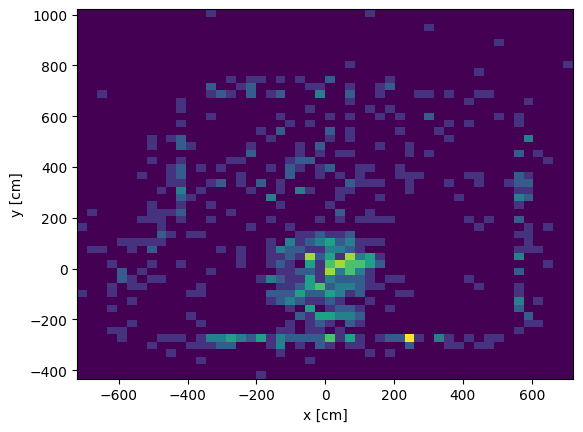

In [15]:
plt.hist2d(Interactions['x_vert'], Interactions['y_vert'], bins = [50, 50])
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.show()

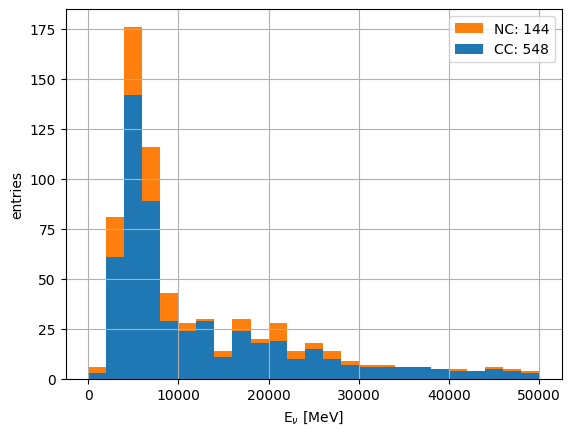

In [16]:
CC = Interactions[Interactions['isCC']==1]['Enu']
NC = Interactions[Interactions['isCC']==0]['Enu']
Enu_CCNC = [CC, NC]
label = [f"CC: {len(CC)}", f"NC: {len(NC)}"]
plt.hist(Enu_CCNC, histtype='stepfilled', stacked=True, label=label, bins=25, range=(0,50000))
plt.xlabel("E$_{\\nu}$ [MeV]")
plt.ylabel("entries")
plt.grid()
plt.legend()
plt.show()

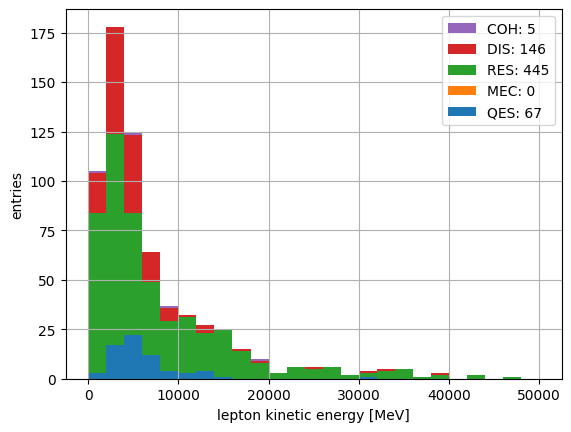

In [17]:
QES = Interactions[Interactions['reaction']==1]['Elep']
MEC = Interactions[Interactions['reaction']==2]['Elep']
RES = Interactions[Interactions['reaction']==3]['Elep']
DIS = Interactions[Interactions['reaction']==4]['Elep']
COH = Interactions[Interactions['reaction']==5]['Elep']

Elep = [QES, MEC, RES, DIS, COH]
label = [f"QES: {len(QES)}", f"MEC: {len(MEC)}", f"RES: {len(RES)}", f"DIS: {len(DIS)}", f"COH: {len(COH)}"]
plt.hist(Elep, histtype='stepfilled', stacked=True, label=label, bins=25, range=(0,50000))
plt.xlabel("lepton kinetic energy [MeV]")
plt.ylabel("entries")
plt.grid()
plt.legend()
plt.show()

Let's plot something from edep segments!

In [18]:
Segs = f_manager["mc_truth/segments/data"]

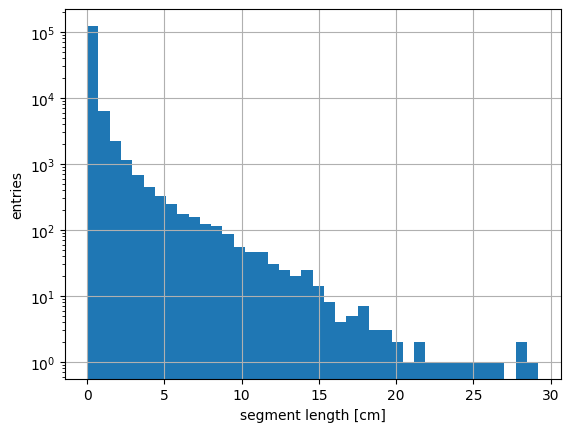

In [19]:
plt.hist(Segs[Segs['dx']>0]['dx'],bins=40)
plt.ylabel("entries")
plt.xlabel("segment length [cm]")
plt.yscale("log")
plt.grid()
plt.show()

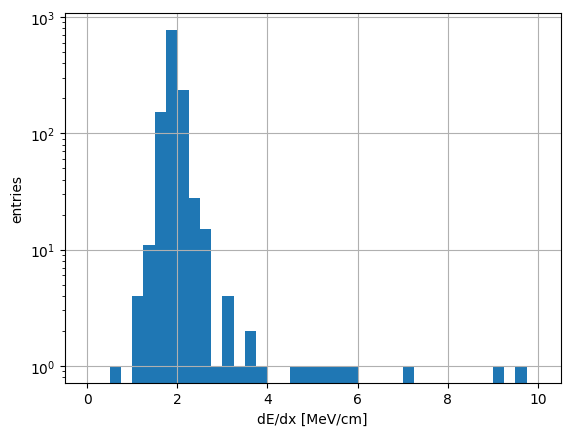

In [20]:
plt.hist(Segs[(Segs['dx']>0)&(Segs['pdg_id']==13)]['dEdx'],bins=40,range=[0,10])
plt.ylabel("entries")
plt.xlabel("dE/dx [MeV/cm]")
plt.yscale("log")
plt.grid()
plt.show()

# Get prompt and final hits of this event

You can load all the calib_final_hits as such:

In [21]:
FinalHits = f_manager["charge/calib_final_hits/data"]

In [22]:
FinalHits.shape

(117001,)

You can also load the entire hits stacks with respect to the events layout.

In [23]:
FinalHits_evts = f_manager["charge/events", "charge/calib_final_hits"]

It has the shape of [number of reco events] x [max number of calib_final_hits in any event]. You can tell that there are a lot of paddings in this product.

In [24]:
FinalHits_evts.shape

(189, 11669)

First, to get the prompt hits (raw hits just converted from packets for x, y, z, Q and E) from this event.

In [25]:
PromptHits_ev = f_manager["charge/events", "charge/calib_prompt_hits", i_evt]

You could also use "dereference" from h5flow directly, but it can gets messy when you have an extensive reference chain.

In [26]:
PromptHits_dref_ev = dereference(i_evt
    ,ref    = f_h5['charge/events/ref/charge/calib_prompt_hits/ref']
    ,region = f_h5['charge/events/ref/charge/calib_prompt_hits/ref_region']
    ,data   = f_h5['charge/calib_prompt_hits/data']
)

Also, to get the final hits ("calibrated" and merged hits which are derived from the prompted hits) from this event. Note in the current flow version, calibration is preliminary, but this data product will be the most direct charge readout interface for the downstream analysis.

In [27]:
FinalHits_ev = f_manager["charge/events", "charge/calib_final_hits", i_evt]

"FinalHits_ev" and "PromptHits_ev" have the same fields which you can check by calling "FinalHits_ev.dtype" for example. The "id" is the index of either final or prompt hits within this file.
You can find what's in there by simply putting "FinalHits_ev" or "FinalHits_ev.data" in a cell and hitting "enter".

In [28]:
FinalHits_ev.dtype

dtype([('id', '<u4'), ('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('t_drift', '<f8'), ('ts_pps', '<u8'), ('io_group', '<u8'), ('io_channel', '<u8'), ('chip_id', '<u8'), ('channel_id', '<u8'), ('Q_raw', '<f8'), ('Q', '<f8'), ('E', '<f8'), ('is_disabled', '?')])

You can visualize the prompt hits and final hits by using plotly for example.

Adding the anode and cathode planes for visual aids. I cheated a little by pulling these TPC boundary limits manually from the geometry configuration file. 

In [29]:
# HACK: this extracts the boundaries for the old implementation,
#       if possible we should emulate the ndlar_flow event display
x_boundaries, y_boundaries, z_boundaries = [
    np.unique(
        f_manager['geometry_info']
        .attrs['module_RO_bounds'][:,:,i]
        .round(decimals=4)
    )
    for i in range(3)
]

def draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries)/2)):
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = (x_boundaries[i_x * 2] + x_boundaries[i_x * 2 + 1]) * 0.5 * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))

    return traces

def draw_anode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries))):           
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = x_boundaries[i_x] * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))
    
    return traces

Plot the prompt and final hits in the detector.\
You can hover your cursor over the plot to see hits' positions and energies.\
Note that the hits x,y,z are in [cm], Q is in [ke-] and E is in [MeV]. 

In [30]:
fig = go.Figure()

##########################
# Draw the cathodes
##########################
fig.add_traces(draw_cathode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.3,
    colorscale='Greys',
))

##########################
# Draw the anodes
##########################
fig.add_traces(draw_anode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.1,
    colorscale='ice',
))

##########################
# Draw the prompt hits
##########################
PHits_traces = go.Scatter3d(
        x=PromptHits_ev.data['x'].flatten(), y=PromptHits_ev.data['y'].flatten(), z=PromptHits_ev.data['z'].flatten(),
        marker_color=PromptHits_ev.data['E'].flatten(),
        name='prompt hits',
        mode='markers',
        visible='legendonly',
        marker_size=3,
        marker_symbol='square',
        showlegend=True,
        opacity=0.7,
        customdata=PromptHits_ev.data['E'].flatten(),
        hovertemplate='<b>x:%{x:.3f}</b><br>y:%{y:.3f}<br>z:%{z:.3f}<br>E:%{customdata:.3f}',
        )
fig.add_traces(PHits_traces)

##########################
# Draw the final hits
##########################
FHits_traces = go.Scatter3d(
        x=FinalHits_ev.data['x'].flatten(), y=FinalHits_ev.data['y'].flatten(), z=FinalHits_ev.data['z'].flatten(),
        marker_color=FinalHits_ev.data['E'].flatten(),
        name='final hits',
        mode='markers',
        visible='legendonly',
        marker_size=3,
        marker_symbol='square',
        showlegend=True,
        opacity=1.,
        customdata=FinalHits_ev.data['E'].flatten(),
        hovertemplate='<b>x:%{x:.3f}</b><br>y:%{y:.3f}<br>z:%{z:.3f}<br>E:%{customdata:.3f}'
        )
fig.add_traces(FHits_traces)

fig.update_layout(
    width=1024, height=768,
    legend_orientation="h",
    scene = dict(xaxis_title='x [cm]',
                yaxis_title='y [cm]',
                zaxis_title='z [cm]')
)


fig.show()

# Get prompt hits which are associated to the final hits in this event

In [31]:
Final_PromptHits = f_manager["charge/events", "charge/calib_final_hits", "charge/calib_prompt_hits",i_evt]

The "Final_PromptHits" is in a shape of [number of events] (we chose one event here) x [number of final hits] x [maximum number of the prompt hits that merged into one final hit].

In [32]:
Final_PromptHits.shape

(1, 1764, 6)

For example, you can check what contribute to the 1st final hit:

In [33]:
Final_PromptHits[0][1]

masked_array(data=[(9352, 32.495957575432286, -20.618099212646484, 53.67470169067383, 1979.0, 4001977, 1, 23, 74, 42, 11.058119344057529, 11.058119344057529, 0.37216821834121966, False),
                   (23637, -30.33730359191224, -12.193499565124512, -19.532899856567383, 1718.0, 2001716, 7, 22, 46, 31, 16.479939244227822, 16.479939244227822, 0.554643103050951, False),
                   (44697, -15.793621479486685, -6.872700214385986, -31.94809913635254, 807.0, 805, 7, 22, 40, 0, 21.745716961691308, 21.745716961691308, 0.7318662863350439, False),
                   (62689, 39.456490397624975, -51.65610122680664, 54.118099212646484, 1543.0, 1541, 1, 31, 74, 18, 23.20851795764528, 23.20851795764528, 0.7810978078545243, False),
                   (83148, 6.151048487274791, -11.306699752807617, 25.297100067138672, 203.0, 201, 2, 22, 48, 18, 7.515640889532042, 7.515640889532042, 0.2529437956421288, False),
                   (112686, 55.56469594256173, -58.307098388671875, 48.7972984313

For example, you can check what contribute to the 1st final hit:

In [34]:
FinalHits_ev.shape

(1, 1764)

You can check the 1st final hit in event 68, which should match with the two original prompt hits by x, y, z, time etc. Currently, the reference from the final hits to the prompt hits is messed up. We will fix it in the next flow sample.

In [35]:
FinalHits_ev[0][0]

(9347, 62.73276758743448, -51.21269989013672, 20.863100051879883, 85.0, 4000083, 1, 26, 46, 48, 21.84016013429047, 21.84016013429047, 0.7350448329022422, False)

# Find the associated true edepsim segments to a hit (Backtracking)

Backtrack from the hits to edepsim segments. \
Unfortunately, the `mc_truth/packet_fraction` dataset seems to non-trivial to use now (working on fixing it). To get to the segment fractional contribution on hits, use `calib_final_hit_backtrack` and `calib_prompt_hit_backtrack`. Original example from Kevin: https://github.com/DUNE/ndlar_flow/pull/78 

In [36]:
Segs_FinalHits = f_manager["charge/events","charge/calib_final_hits","charge/calib_prompt_hits","charge/packets", "mc_truth/segments", i_evt]

Each reference will expand the dimension of the resulted array, so be cautious of that.\
Take the shape of "Segs_FinalHits" as an example.\
The first axis indicates one event.\
The second axis shows the number of final hits in this event.\
The third axis gives the maximum number of prompt hits associated to any final hits in this event.\
The fourth axis should always be 1 which shows that "charge/calib_prompt_hits" and "charge/packets" have one to one correspondence.\
The last axis is passed on from larnd-sim, where we allow maximum 10 segments associated to one packet (hit).

<table style="margin-left: 0; margin-right: auto;">
<tr><td>

| Axis | Dataset | Description |
| :--: | :-----: | :---------: |
|  0   | `charge/events` | There is one event since we indexed into `i_evt`. |
|  1   | `charge/calib_final_hits` | The number of final hits in this event. |
|  2   | `charge/calib_prompt_hits` | The maxmium number of prompt hits associated to any final hits in this event. |
|  3   | `charge/packets` | Each data packet is associated to a prompt hit, which shows the one-to-one correspondence of `"charge/calib_prompt_hits"` and `"charge/packets"`. |
|  4   | `mc_truth/segments` | larnd-sim allows at most 20 segments associated to one packet. |
</td></tr>
</table>
If the number of values associated with the previous reference is less than maximum, the dimension is right padded with masked values.

In [37]:
Segs_FinalHits.shape

(1, 1764, 6, 1, 20)

In [38]:
Segs_FinalHits[0][99]['pdg_id'].data

array([[[ -13,  -13,   11,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[2212, 2212,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[  11,   11,   11,   11,   11,   11,   11,   11,   11,   11,
           11,   11,   11,   11,   11,   11,   11,   11,   11,   11]],

       [[ -13,  -13,   11,   11,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[ -11,  -11,  -11,  -11,  -11,  -11,  -11,  -11,  -11,  -11,
          -11,   11,   11,   11,   11,   11,   11,   11,   11,   11]],

       [[2212, 2212,   11,   11,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]]],
      dtype=int32)

In [39]:
Segs_FinalHits[0][99]['segment_id'].data

array([[[ 13816,  13817,  13833,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[ 25816,  25817,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[ 49318,  49319,  49320,  49323,  49360,  49361,  50303,  50304,
          50305,  50307,  51865,  51866,  51867,  51868,  51869,  51870,
          51871,  51872,  51873,  51876]],

       [[ 68840,  68841,  68859,  68860,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[ 88515,  88516,  88517,  88518,  88519,  88520,  88521,  88522,
          88523,  88524,  88525,  88609,  88613,  88628,  88629,  88633,
          88968,  88969,  88970,  88971]],

       [[118133, 118134, 118178, 118179,      0,  

In [40]:
Segs_FinalHits[0][99]['event_id'].data

array([[[123022, 123022, 123022,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[123051, 123051,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[123075, 123075, 123075, 123075, 123075, 123075, 123075, 123075,
         123075, 123075, 123075, 123075, 123075, 123075, 123075, 123075,
         123075, 123075, 123075, 123075]],

       [[123110, 123110, 123110, 123110,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0]],

       [[123140, 123140, 123140, 123140, 123140, 123140, 123140, 123140,
         123140, 123140, 123140, 123140, 123140, 123140, 123140, 123140,
         123140, 123140, 123140, 123140]],

       [[123164, 123164, 123164, 123164,      0,  

In [41]:
Segs_FinalHits[0][99]['traj_id'].data

array([[[   0,    0,   38,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[1034, 1034,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[2128, 2128, 2128, 2128, 2349, 2349, 3013, 3013, 3013, 3013,
         4153, 4153, 4153, 4153, 4153, 4153, 4153, 4153, 4165, 4163]],

       [[   0,    0,  898,  897,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],

       [[   9,    9,    9,    9,    9,    9,    9,    9,    9,    9,
            9,   27,   91,   24,   23,  103,    8,    8,    8,    8]],

       [[ 200,  200,  287,  286,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0]]],
      dtype=int32)

Final hits backtrack is broken in 6.4 and 6.5.

In [42]:
f_name_MR62 = 'MiniRun6.2_1E19_RHC.flow.0000123.FLOW.hdf5'
f_manager_MR62 = h5flow.data.H5FlowDataManager(f_name_MR62, 'r')

In [43]:
Segs_Contribs_FinalHits = f_manager_MR62["charge/events","charge/calib_final_hits", "mc_truth/calib_final_hit_backtrack", i_evt]

In [44]:
Segs_Contribs_FinalHits.shape

(1, 2344, 1)

In [45]:
Segs_FinalHits[0][99].data

array([[[(123022, 1000001231003330,  13816,  33.21641  ,    0,  63150, 0.05521498,  32.361507 ,  36.45523 ,   6.2001834,  42797,  -13,  36.416374,   6.278377 , 181.30002509, 2.64000082e+07, 2.64000082e+07, 2.64000082e+07, 8.5935163e-01, 0.03722593, 0, 181.42172149, 181.5434179 ,   1.7898974,  1.5381513 , 0.,   6.23928  ,  36.435802 ,  32.78896  ,  32576.553  ),
         (123022, 1000001231003330,  13817,  39.079792 ,    0,  63150, 0.05506083,  33.21641  ,  36.724754,   5.665083 , 298826,  -13,  36.45523 ,   6.2001834, 179.61187221, 2.64000082e+07, 2.64000082e+07, 2.64000082e+07, 5.8939128e+00, 0.037122  , 0, 180.45600513, 181.30013806,   1.8254602, 10.759103  , 0.,   5.9326334,  36.589993 ,  36.1481   , 228584.86   ),
         (123022, 1000001231003330,  13833,  33.259453 ,   38,  63188, 0.05523418,  33.21641  ,  36.37789 ,   6.173001 ,  14637,   11,  36.45523 ,   6.2001834, 181.30004208, 2.64000082e+07, 2.64000082e+07, 2.64000082e+07, 9.2589349e-02, 0.03723888, 0, 181.54226405, 181.78

In [46]:
Segs_Contribs_FinalHits[0][99].data

array([([0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])],
      dtype=[('event_ids', '<i8', (1,)), ('segment_ids', '<i8', (20,)), ('fraction', '<f8', (20,)), ('file_traj_ids', '<i8', (20,)), ('fraction_traj', '<f8', (20,))])

Similarly, you can backtrack from the prompt hits to edepsim segments. This is working in MiniRun6.5. 

In [47]:
Segs_PromptHits = f_manager["charge/events","charge/calib_prompt_hits","charge/packets", "mc_truth/segments", i_evt]

In [48]:
Segs_PromptHits.shape

(1, 2357, 1, 20)

We can also get the associated interaction information to each prompt hit.

In [49]:
Ints_PromptHits = f_manager["charge/events","charge/calib_prompt_hits","charge/packets", "mc_truth/segments", "mc_truth/interactions", i_evt]

In [50]:
Ints_PromptHits.shape

(1, 2357, 1, 20, 1)

Cheating here. Let's only look at the single segment with the largest contribution backtracked to a prompt hit to trace the vertex. 

In [51]:
Ints_PHits_ev = Ints_PromptHits.data[0,:,0,0,0]

Build a function to check if a vertex position is in the active volume. We can get the detector boundary for the LAr volume in `geometry_info`.

In [52]:
lar_bounds = f_manager["geometry_info"].attrs["lar_detector_bounds"]
def vtx_in_LArActive(verts, lar_bounds=lar_bounds):
    return np.all((lar_bounds[0] <= verts) & (verts <= lar_bounds[1]),-1)

Define a function to plot edep-sim segments.

In [53]:
def plot_segs(segs, **kwargs):
    
    def to_list(axis):
        return np.column_stack([
            segs[f'{axis}_start'],
            segs[f'{axis}_end'],
            np.full(len(segs), None)
        ]).flatten().tolist()
        
    x, y, z = (to_list(axis) for axis in 'xyz')

    trace = go.Scatter3d(x=x, y=y, z=z, **kwargs)
    
    return trace

Here we plot the prompt hits again. The color now indicates the associated trackID from truth info. When you hover on a hit, it will show you the position of the hit and the pdg code of the associated segment. It will also plot the associated vertices if they are in the active volume. The hits associated segments are also drawn in the plot.

In [54]:
fig = go.Figure()

plot_outActive_vertices = True

##########################
# Draw the cathodes
##########################
fig.add_traces(draw_cathode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.3,
    colorscale='Greys',
))

##########################
# Draw the anodes
##########################
fig.add_traces(draw_anode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.1,
    colorscale='ice',
))

##########################
# Draw the prompt hits
##########################
PHits_traces = go.Scatter3d(
        x=PromptHits_ev.data['x'].flatten(), y=PromptHits_ev.data['y'].flatten(), z=PromptHits_ev.data['z'].flatten(),
        marker_color=Segs_PromptHits[0,:,0,0]['segment_id'],
        name='prompt hits',
        mode='markers',
        visible='legendonly',
        marker_size=3,
        marker_symbol='square',
        showlegend=True,
        opacity=0.7,
        customdata=Segs_PromptHits[0,:,0,0]['pdg_id'].data,
        hovertemplate='<b>x:%{x:.3f}</b><br>y:%{y:.3f}<br>z:%{z:.3f}<br>pdg_id:%{customdata:d}',
        )
fig.add_traces(PHits_traces)

##########################
# Draw the vertices that are in the active LAr
##########################
# Many hits will trace back to same vertices. Let's get rid some repetition here.
vtxID_uniq_ev, vtx_idx = np.unique(Ints_PHits_ev['vertex_id'], return_index=True)
unique_Ints = np.take(Ints_PHits_ev, vtx_idx[vtxID_uniq_ev != 0]) # vertex_id == 0 are masked
Vtx_traces = []
for i_vtx, vtx in enumerate(unique_Ints):
    if plot_outActive_vertices or vtx_in_LArActive( [vtx['x_vert'], vtx['y_vert'], vtx['z_vert']]):
        Vtx_traces.append(go.Scatter3d(
        x=[vtx['x_vert']], y=[vtx['y_vert']], z=[vtx['z_vert']],
        marker_color='red',
        name=f'vertex{i_vtx}',
        mode='markers',
        visible='legendonly',
        marker_size=5,
        marker_symbol='circle',
        showlegend=True,
        opacity=0.7
        ))
fig.add_traces(Vtx_traces)
if len(Vtx_traces) == 0:
    print("No vertices in the active LAr volume!")


##########################
# Draw associated segments
##########################
Segs_traces = plot_segs(Segs_PromptHits[0,:,0,0], 
                    mode="lines",
                    name="edep segments",
                    visible='legendonly',
                    line_color='red',
                    showlegend=True
                    )
fig.add_traces(Segs_traces)

fig.update_layout(
    width=1024, height=768,
    legend_orientation="h",
    scene = dict(xaxis_title='x [cm]',
                 yaxis_title='y [cm]',
                 zaxis_title='z [cm]')    
)

fig.show()

# From MC truth to the reco hits!

Get the prompt hits associated to the first neutrino interaction in this file.

In [55]:
PHits_Segs_Ints = f_manager["mc_truth/interactions", "mc_truth/segments", "charge/packets", "charge/calib_prompt_hits",0]

In [56]:
PHits_Segs_Ints.shape

(1, 25, 4, 1)

# Light!

Let's have a look what's in the light dataset!

In [57]:
f_manager["light"].keys()

<KeysViewHDF5 ['cwvfm', 'events', 'flash', 'sipm_hits', 'stpc_wvfm', 'sum_hits', 'sum_tpc_hits', 'swvfm', 't_ns', 'wvfm']>

It is a lot simpler in MiniRun4.5, we will use only these fields in this tutorial.

In [58]:
f_manager_MR4['light'].keys()

<KeysViewHDF5 ['events', 'sipm_hits', 'sum_hits', 't_ns', 'wvfm']>

You may notice that in MiniRun4.5 files, there are a lot more light events than the charge events. This is because the forced beam trigger on light readout in larnd-sim was written out per module. It is corrected in MiniRun5 simulation!

In [59]:
max(f_manager_MR4["charge/events/data"]['id'])

np.uint64(125)

In [60]:
max(f_manager_MR4["light/events/data"]['id'])

np.uint64(405)

In [61]:
f_manager_MR4["light/events/data"]['utime_ms'][:,0]

array([     0,   1200,   1200,   1200,   1200,   2400,   2400,   3600,
         4800,   4800,   4800,   4800,   6000,   6000,   6000,   7200,
         9600,   9600,  10800,  10800,  12000,  13200,  14400,  14400,
        14400,  14400,  16800,  16800,  19200,  19200,  20400,  20400,
        20400,  21600,  22800,  25200,  25200,  25200,  26400,  26400,
        26400,  26400,  27600,  28800,  28800,  30000,  31200,  31200,
        32400,  32400,  32400,  32400,  33600,  33600,  33600,  33600,
        34800,  36000,  37200,  37200,  37200,  38400,  38400,  38400,
        39600,  39600,  40800,  44400,  44400,  45600,  45600,  45600,
        46800,  48000,  48000,  48000,  48000,  49200,  49200,  50400,
        50400,  50400,  51600,  55200,  56400,  56400,  57600,  57600,
        57600,  58800,  58800,  61200,  61200,  61200,  61200,  62400,
        62400,  63600,  63600,  63600,  64800,  64800,  66000,  66000,
        67200,  67200,  67200,  67200,  68400,  68400,  68400,  70800,
      

In comparison, MiniRun5's light event fits the 2x2 operating logics for beam triggering. Every simulated beam charge event corresponds to a light event. No matter if there is any LArPix packets.

In [62]:
max(f_manager["charge/events/data"]['id'])

np.uint64(188)

In [63]:
max(f_manager["light/events/data"]['id'])

np.uint64(188)

In [64]:
f_manager["light/events/data"]['utime_ms'][:, 0]

array([     0,   1200,   2400,   3600,   4800,   6000,   7200,   8400,
         9600,  10800,  12000,  13200,  14400,  15600,  16800,  18000,
        19200,  20400,  21600,  22800,  24000,  25200,  26400,  27600,
        28800,  30000,  31200,  32400,  33600,  34800,  36000,  37200,
        38400,  39600,  40800,  42000,  43200,  44400,  45600,  46800,
        48000,  49200,  50400,  51600,  52800,  54000,  55200,  56400,
        57600,  58800,  60000,  61200,  62400,  63600,  64800,  66000,
        67200,  68400,  69600,  70800,  72000,  73200,  74400,  75600,
        76800,  78000,  79200,  80400,  81600,  82800,  84000,  85200,
        86400,  87600,  88800,  90000,  91200,  92400,  93600,  94800,
        96000,  97200,  98400,  99600, 100800, 102000, 103200, 104400,
       105600, 106800, 108000, 109200, 110400, 111600, 112800, 114000,
       116400, 117600, 118800, 120000, 121200, 122400, 123600, 124800,
       126000, 127200, 128400, 129600, 130800, 132000, 133199, 134400,
      

Let's look at the clock reset in the simulation. MiniRun4.5 uses LArPix internal rollover 2^31 (ticks, 0.1us/tick).

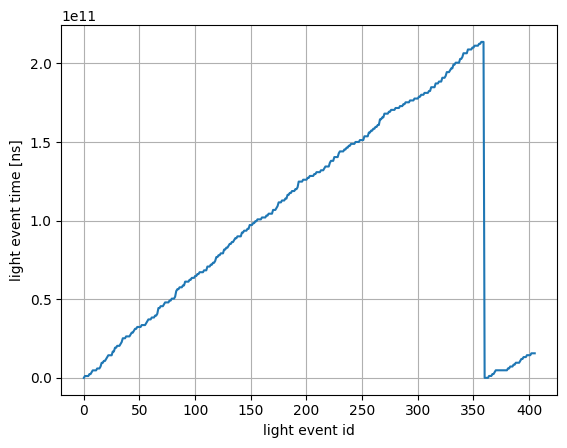

In [65]:
plt.plot(f_manager_MR4["light/t_ns/data"]['t_ns'][:, 0])
plt.xlabel("light event id")
plt.ylabel("light event time [ns]")
plt.grid()
plt.show()

MiniRun5 has PPS reset implemented in the charge and light simulation.

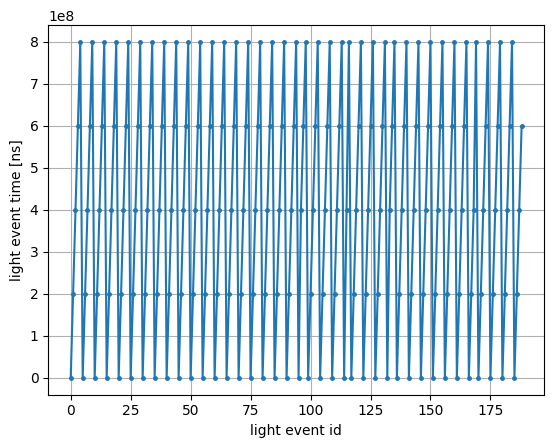

In [66]:
plt.plot(f_manager["light/t_ns/data"]['t_ns'][:, 0], '-o', markersize=2.5)
plt.xlabel("light event id")
plt.ylabel("light event time [ns]")
plt.grid()
plt.show()

Let's have a look of the light readout waveform!

The first axis is the number of light triggers/light events.\
The second axis is the number of ADC's.\
The third axis is the ADC channels.\
The fourth axis is the light readout sampling.

In [67]:
f_manager["light/wvfm/data"]['samples'].shape

(189, 8, 64, 1000)

An example waveform

In [68]:
i_adc = 1
i_adc_ch = 57

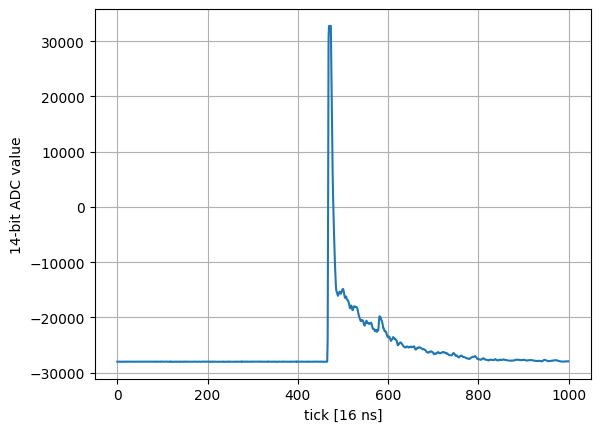

In [69]:
plt.plot(f_manager["light/wvfm/data"]['samples'][i_evt,i_adc,i_adc_ch,:])
plt.xlabel("tick [16 ns]")
plt.ylabel("14-bit ADC value")
plt.grid()
plt.show()

Find the sipm hits in this light event

In [70]:
sipm_hits_evt = f_manager["light/events", "light/sipm_hits", i_evt]

In [71]:
sipm_hits_evt_ch = sipm_hits_evt[(sipm_hits_evt["adc"]==i_adc)&(sipm_hits_evt["chan"]==i_adc_ch)]

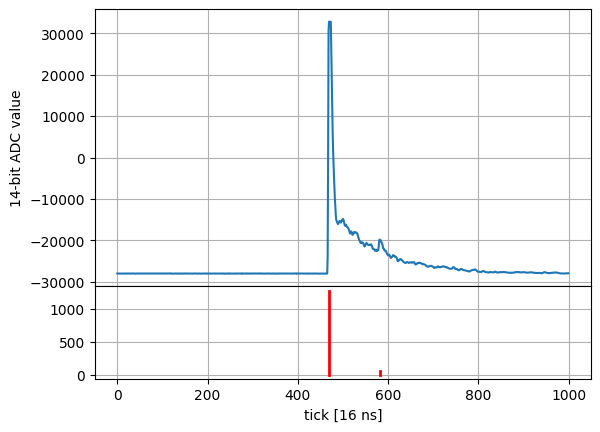

In [72]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, height_ratios=[3,1])
fig.subplots_adjust(hspace=0)
ax1.plot(f_manager["light/wvfm/data"]['samples'][i_evt,i_adc,i_adc_ch,:])
ax2.set_xlabel("tick [16 ns]")
ax1.set_ylabel("14-bit ADC value")
ax1.grid()
for x, y in zip(sipm_hits_evt_ch["sample_idx"], sipm_hits_evt_ch["max_spline"]):
    ax2.plot([x,x], [0,y], color="red", linewidth=2)
ax2.grid()
plt.show()

Check where is this light signal read out

Load the sipm and detector location LUT's. Thank you Livio!

In [73]:
from proto_nd_flow.util.lut import LUT

Hello


In [74]:
sipm_abs_pos = LUT.from_array(f_manager["geometry_info/sipm_abs_pos"].attrs["meta"],f_manager["geometry_info/sipm_abs_pos/data"])
sipm_rel_pos = LUT.from_array(f_manager["geometry_info/sipm_rel_pos"].attrs["meta"],f_manager["geometry_info/sipm_rel_pos/data"])
det_bounds = LUT.from_array(f_manager["geometry_info/det_bounds"].attrs["meta"],f_manager["geometry_info/det_bounds/data"])
det_rel_pos = LUT.from_array(f_manager["geometry_info/det_rel_pos"].attrs["meta"],f_manager["geometry_info/det_rel_pos/data"])
det_id = LUT.from_array(f_manager["geometry_info/det_id"].attrs["meta"],f_manager["geometry_info/det_id/data"])

sipm_abs_pos[(adc,chan)] = [x,y,z] in cm

In [75]:
sipm_abs_pos[(i_adc,i_adc_ch)]

array([[ 3.06, -2.61,  2.01]], dtype=float32)

sipm_rel_pos[(adc,chan)] = [tpc, side, vertical position] \
side: 0->left 1->right looking in drift direction \
vertical position: index starting from bottom (0-23)

In [76]:
sipm_rel_pos[(i_adc,i_adc_ch)]

array([[ 1,  0, 11]], dtype=int32)

det_id[(adc,chan)] = det_id \
0-16 for each TPC, counting from bottom (start with ArcLight)\
The one we have is a LCM.

In [77]:
det_id[(i_adc,i_adc_ch)]

array([3], dtype=int32)

In [78]:
det_id[5,2]#10,11,58,59

array([-1], dtype=int32)

In [79]:
np.unique([det_id[5,i] for i in range(64)])

array([-1,  1,  2,  3,  5,  6,  7,  9, 10, 11, 13, 14, 15], dtype=int32)

In [80]:
this_tpc = sipm_rel_pos[i_adc,i_adc_ch][0][0]
this_light_det = det_id[i_adc,i_adc_ch][0]

In [81]:
this_light_det

np.int32(3)

det_bounds[(tpc,det)] = [[x_min, y_min, z_min],[x_max, y_max, z_max]] in cm \
Indeed, LCM!

In [82]:
det_bounds[this_tpc, this_light_det]

array([[[ 3.060e+00, -1.033e+01,  2.010e+00],
        [ 3.023e+01,  1.000e-02,  2.010e+00]]], dtype=float32)

det_rel_pos[(tpc,det)] = [tpc, side, vertical position] \
side: 0->left 1->right looking in drift direction \
vertical position: index starting from bottom (0-15)

In [83]:
det_rel_pos[this_tpc, this_light_det]

array([[1, 0, 3]], dtype=int32)

Let's check the sum_hits. It is very similar to `sipm_hits`, except it has the fields of "tpc", "det", "boundary" instead of "adc", "chan", "pos"

In [84]:
sum_hits_evts = f_manager["light/events", "light/sum_hits", i_evt]

In [85]:
sum_hits_evts

masked_array(data=[[(902, 0, 0, [[33.65999984741211, -62.040000915527344, 2.009999990463257], [60.83000183105469, -31.020000457763672, 2.009999990463257]], 470, 400000099.0, 5920.0, [0.42544499039649963, 1.9797208309173584, 4.35684871673584, 5.911124229431152, 4.17399263381958, 4.173993110656738, 4.63113260269165, 2.802572727203369, 2.5282888412475586], 30.98311996459961, 5.911124229431152, 29.38376235961914, 5.9256696701049805, -17.31764793395996, 0.0, 0.0, -1.0190221071243286),
                    (903, 0, 0, [[33.65999984741211, -62.040000915527344, 2.009999990463257], [60.83000183105469, -31.020000457763672, 2.009999990463257]], 617, 400000099.0, 8272.0, [-0.5802630186080933, 1.6140090227127075, 3.2597126960754395, 5.45398473739624, 3.9911367893218994, 4.173993110656738, 3.442568778991699, 2.4368607997894287, 1.3397250175476074], 25.131729125976562, 5.45398473739624, 25.1569766998291, 5.455636501312256, -15.81176471710205, 0.0, 0.0, 1.9367247819900513),
                    (904, 0,

In [86]:
sum_hits_evts_det = sum_hits_evts[(sum_hits_evts["tpc"]==this_tpc)&(sum_hits_evts["det"]==this_light_det)]

In [87]:
sum_hits_evts_det

masked_array(data=[(942, 1, 3, [[3.059999942779541, -10.329999923706055, 2.009999990463257], [30.229999542236328, 0.009999999776482582, 2.009999990463257]], 469, 400000099.0, 5904.0, [-91.05923461914062, 962.7398681640625, 2353.451171875, 2505.6328125, 2505.6328125, 2505.6328125, 2505.6328125, 2505.6328125, 2209.9091796875], 17963.205078125, 2505.6328125, 16959.447265625, 2539.07958984375, -22.839216232299805, 0.0, 0.0, 1.9212334156036377),
                   (943, 1, 3, [[3.059999942779541, -10.329999923706055, 2.009999990463257], [30.229999542236328, 0.009999999776482582, 2.009999990463257]], 581, 400000099.0, 7696.0, [-7.03690767288208, 34.105690002441406, 91.7967529296875, 118.95086669921875, 112.64234161376953, 107.7966537475586, 95.63673400878906, 84.11680603027344, 74.79115295410156], 712.800048828125, 118.95086669921875, 680.8775634765625, 119.34193420410156, -13.803921699523926, 0.0, 0.0, 5.583891868591309)],
             mask=[(False, False, False, [[False, False, False], [Fa

# Charge-light matching
The charge-light matching is one-to-one since MiniRun5. This is not the case for MiniRun4.5.

charge to light (usual direction)

In [88]:
f_manager_MR4["charge/events","light/events"].shape

(126, 11)

light to charge

In [89]:
f_manager_MR4["light/events", "charge/events"].shape

(406, 1)

In [90]:
f_manager["charge/events","light/events"].shape

(189, 1)

In [91]:
f_manager["light/events", "charge/events"].shape

(189, 1)

In [92]:
i_evt=136

In [93]:
def draw_light_trap(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries)/2)):
            x, y = np.meshgrid(np.linspace(x_boundaries[i_z * 2], x_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            z = (z_boundaries[i_x * 2] + z_boundaries[i_x * 2 + 1]) * 0.5 * np.ones(x.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))

    return traces

In [94]:
PromptHits_ev = f_manager["charge/events", "charge/calib_prompt_hits", i_evt]

In [95]:
Segs_PromptHits = f_manager["charge/events","charge/calib_prompt_hits","charge/packets", "mc_truth/segments", i_evt]

In [96]:
det_x_bound = np.concatenate(det_bounds[this_tpc, this_light_det].T[0])
det_y_bound = np.concatenate(det_bounds[this_tpc, this_light_det].T[1])
det_z_bound = np.concatenate(det_bounds[this_tpc, this_light_det].T[2])

In [97]:
fig = go.Figure()

plot_outActive_vertices = True

##########################
# Draw the cathodes
##########################
fig.add_traces(draw_cathode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.3,
    colorscale='Greys',
))

##########################
# Draw the anodes
##########################
fig.add_traces(draw_anode_planes(
    x_boundaries, y_boundaries, z_boundaries, 
    showscale=False,
    opacity=0.1,
    colorscale='ice',
))

##########################
# Draw the prompt hits
##########################
PHits_traces = go.Scatter3d(
        x=PromptHits_ev.data['x'].flatten(), y=PromptHits_ev.data['y'].flatten(), z=PromptHits_ev.data['z'].flatten(),
        marker_color=Segs_PromptHits[0,:,0,0]['segment_id'],
        name='prompt hits',
        mode='markers',
        visible='legendonly',
        marker_size=3,
        marker_symbol='square',
        showlegend=True,
        opacity=0.7,
        customdata=Segs_PromptHits[0,:,0,0]['pdg_id'].data,
        hovertemplate='<b>x:%{x:.3f}</b><br>y:%{y:.3f}<br>z:%{z:.3f}<br>pdg_id:%{customdata:d}',
        )
fig.add_traces(PHits_traces)


##########################
# Draw associated segments
##########################
Segs_traces = plot_segs(Segs_PromptHits[0,:,0,0], 
                    mode="lines",
                    name="edep segments",
                    visible='legendonly',
                    line_color='red',
                    showlegend=True
                    )
fig.add_traces(Segs_traces)

##########################
# Draw the highlighted light trap
##########################
fig.add_traces(draw_light_trap(
    det_x_bound, det_y_bound, det_z_bound, 
    showscale=False,
    opacity=0.3,
    colorscale='Greys',
))

fig.update_layout(
    width=1024, height=768,
    legend_orientation="h",
    scene = dict(xaxis_title='x [cm]',
                yaxis_title='y [cm]',
                zaxis_title='z [cm]')    
)

fig.show()

# Older MiniRun Versions
Older versions contain some peculiarities that are listed here. I will use MiniRun4.5 to demonstrate them.

In [98]:
f_name_MR4 = 'MiniRun4.5_1E19_RHC.flow.0000123.FLOW.hdf5'
f_manager_MR4 = h5flow.data.H5FlowDataManager(f_name_MR4, 'r')

## Interaction Vertices
In MiniRun6.4 and before except MiniRun5 beta2, `mc_truth/interactions/data` used the field `vertex` organized as a matrix with columns `['x_vert', 'y_vert', 'z_vert', 't_vert']`. `t_event` was not recorded before MiniRun5 beta2.

In [99]:
f_manager_MR4['mc_truth/interactions',:].dtype.names

('event_id',
 'vertex_id',
 'vertex',
 'target',
 'reaction',
 'isCC',
 'isQES',
 'isMEC',
 'isRES',
 'isDIS',
 'isCOH',
 'Enu',
 'nu_4mom',
 'nu_pdg',
 'Elep',
 'lep_mom',
 'lep_ang',
 'lep_pdg',
 'q0',
 'q3',
 'Q2',
 'x',
 'y')

In [100]:
MR4_verts = f_manager_MR4['mc_truth/interactions',:]['vertex']
MR4_verts

array([[ 1.75482447e+02,  6.29178930e+02, -3.65044184e+03,
         2.36414073e+00],
       [-1.42276940e+02,  6.69785310e+01, -2.11723984e+02,
         5.30647553e+00],
       [ 7.59945675e+01, -2.86112092e+02, -2.73749825e+02,
         5.81972380e+00],
       ...,
       [-5.58561913e+02,  6.46895902e+01,  2.56635121e+02,
         2.31600001e+08],
       [ 1.81234488e+01,  4.41397711e+01, -2.25818817e+02,
         2.31600002e+08],
       [-2.76608788e+02,  6.82942093e+02, -1.25642406e+03,
         2.31600007e+08]], shape=(692, 4))

In [101]:
MR6_verts = np.stack([
    f_manager['mc_truth/interactions',:][i+'_vert']
    for i in 'xyzt'
    ],
    axis = -1
)
np.all( np.isclose(MR4_verts, MR6_verts) )

np.True_

## Light Event Recording and Timekeeping
In MiniRun4.5 files, there are a lot more light events than the charge events. This is because the forced beam trigger on light readout in larnd-sim was written out per module. It is corrected in MiniRun5 simulation!

In [102]:
max(f_manager_MR4['charge/events/data']['id'])

np.uint64(125)

In [103]:
max(f_manager_MR4['light/events/data']['id'])

np.uint64(405)

In [104]:
f_manager_MR4["light/events/data"]['utime_ms'][:, 0]

array([     0,   1200,   1200,   1200,   1200,   2400,   2400,   3600,
         4800,   4800,   4800,   4800,   6000,   6000,   6000,   7200,
         9600,   9600,  10800,  10800,  12000,  13200,  14400,  14400,
        14400,  14400,  16800,  16800,  19200,  19200,  20400,  20400,
        20400,  21600,  22800,  25200,  25200,  25200,  26400,  26400,
        26400,  26400,  27600,  28800,  28800,  30000,  31200,  31200,
        32400,  32400,  32400,  32400,  33600,  33600,  33600,  33600,
        34800,  36000,  37200,  37200,  37200,  38400,  38400,  38400,
        39600,  39600,  40800,  44400,  44400,  45600,  45600,  45600,
        46800,  48000,  48000,  48000,  48000,  49200,  49200,  50400,
        50400,  50400,  51600,  55200,  56400,  56400,  57600,  57600,
        57600,  58800,  58800,  61200,  61200,  61200,  61200,  62400,
        62400,  63600,  63600,  63600,  64800,  64800,  66000,  66000,
        67200,  67200,  67200,  67200,  68400,  68400,  68400,  70800,
      

In MiniRun5 and after, charge events are light events are one-to-one.

In [105]:
assert max(f_manager['charge/events/data']['id']) == max(f_manager['light/events/data']['id'])
max(f_manager['charge/events/data']['id'])

np.uint64(188)

In [106]:
f_manager['light/events/data']['utime_ms'][:,0]

array([     0,   1200,   2400,   3600,   4800,   6000,   7200,   8400,
         9600,  10800,  12000,  13200,  14400,  15600,  16800,  18000,
        19200,  20400,  21600,  22800,  24000,  25200,  26400,  27600,
        28800,  30000,  31200,  32400,  33600,  34800,  36000,  37200,
        38400,  39600,  40800,  42000,  43200,  44400,  45600,  46800,
        48000,  49200,  50400,  51600,  52800,  54000,  55200,  56400,
        57600,  58800,  60000,  61200,  62400,  63600,  64800,  66000,
        67200,  68400,  69600,  70800,  72000,  73200,  74400,  75600,
        76800,  78000,  79200,  80400,  81600,  82800,  84000,  85200,
        86400,  87600,  88800,  90000,  91200,  92400,  93600,  94800,
        96000,  97200,  98400,  99600, 100800, 102000, 103200, 104400,
       105600, 106800, 108000, 109200, 110400, 111600, 112800, 114000,
       116400, 117600, 118800, 120000, 121200, 122400, 123600, 124800,
       126000, 127200, 128400, 129600, 130800, 132000, 133199, 134400,
      

# Changes
- [x] Use MiniRun6.5 "*_vert" fields instead of the "vertex" field
- [x] Fetch detector boundaries from "geometry_info" instead of hardcoding (HACK)
- [ ] Fix MiniRun6.5 missing final hit backtracking (prompt hit tracks normally)
- [x] Add reference to 2x2 wiki
- [x] Add file locations
- [ ] Add reference to mapfiles.py
- [ ] Add reference to interactive event display
- [x] Use tables to explain indexing
- [x] Use a table for the Coordinates section
## Other Ideas
- Display prompt hits by default in the first event display, the segments and fiducial vertices in the 2nd, and prompt hits in the 3rd. And add note to click on the legends.
- `mc_truth/interactions/data` -> `t_event`\[us\](spill/event time) is not recorded anywhere else since 2x2 wiki is outdated.
- Move changes between versions to the end or remove completely; Ideally replaced with a link to a changelog.
## Problems
- MiniRun 6.5 `charge/calib_final_hits` does not have a reference to `mc_truth/calib_final_hit_backtrack`, so the backtracking sample does not run properly, using a previous version (6.2) creates a mismatch of shape for the same event.
    - I also failed to find an event with 2 prompt hits corresponding to 1 final hit.
- We can have 20 segments correspond to each charge packet in MiniRun6. Is this change permanent and is the description still correct?
- Baseline signal of both light detectors are not zeroed, current solution in event display is to take the average of first 50 samples as baseline, should it be incorporated here?